# EEGNet Performance Dashboard

This notebook loads training artifacts (`results.csv` and run log) and shows:
- Summary metrics table
- Metric bar chart
- Training curves (loss/F1 over epochs) parsed from log

In [1]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

# Focal+WeightedSampler run artifacts
RUN_NAME = "notebook_binary_run"
ROOT = Path("/mount/NAS-workspace-portal/eeg2025-Vistec")

RESULTS_CSV = ROOT / "jobs" / RUN_NAME / "results.csv"
LOG_FILE = ROOT / "jobs" / "logs" / "eeg_focal_ws_n100_094425.log"

print(f"Results CSV: {RESULTS_CSV}")
print(f"Log file:    {LOG_FILE}")
print(f"CSV exists:  {RESULTS_CSV.exists()}")
print(f"Log exists:  {LOG_FILE.exists()}")

Results CSV: /mount/NAS-workspace-portal/eeg2025-Vistec/jobs/notebook_binary_run/results.csv
Log file:    /mount/NAS-workspace-portal/eeg2025-Vistec/jobs/logs/eeg_focal_ws_n100_094425.log
CSV exists:  True
Log exists:  True


Latest metrics row:


,testing_loss,accuracy,sensitivity,specificity,f1-score-binary,f1-score-macro,f1-score-weighted,balanced_accuracy_score,roc_auc_score,cohen_kappa_score
0,0.192731,0.291163,0.0,1.0,0.0,0.225504,0.131317,0.5,0.509803,0.0


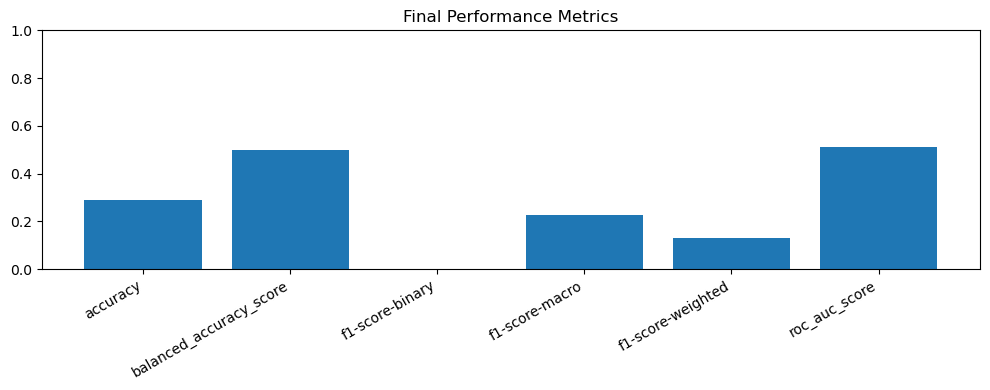

In [2]:
# 1) Final metrics table from results.csv
if not RESULTS_CSV.exists():
    print("results.csv not found yet. Wait for training to finish.")
else:
    results_df = pd.read_csv(RESULTS_CSV)
    print("Latest metrics row:")
    display(results_df.tail(1))

    if not results_df.empty:
        latest = results_df.iloc[-1]
        metrics_to_plot = [
            "accuracy",
            "balanced_accuracy_score",
            "f1-score-binary",
            "f1-score-macro",
            "f1-score-weighted",
            "roc_auc_score",
        ]
        metrics_to_plot = [m for m in metrics_to_plot if m in results_df.columns]

        plot_df = latest[metrics_to_plot].astype(float).reset_index()
        plot_df.columns = ["metric", "value"]

        plt.figure(figsize=(10, 4))
        plt.bar(plot_df["metric"], plot_df["value"])
        plt.ylim(0, 1)
        plt.xticks(rotation=30, ha="right")
        plt.title("Final Performance Metrics")
        plt.tight_layout()
        plt.show()

Parsed 100 epochs from log.


,epoch,epochs_total,train_loss,train_f1,val_loss,val_f1
90,91,100,0.1847,0.0019,0.1925,0.0
91,92,100,0.1853,0.0026,0.1923,0.0
92,93,100,0.1856,0.0028,0.1925,0.0
93,94,100,0.1851,0.0000,0.1923,0.0
94,95,100,0.1855,0.0034,0.1922,0.0
95,96,100,0.1839,0.0031,0.1921,0.0
96,97,100,0.1841,0.0009,0.1919,0.0
97,98,100,0.1853,0.0008,0.1920,0.0
98,99,100,0.1849,0.0015,0.1921,0.0
99,100,100,0.1852,0.0009,0.1921,0.0


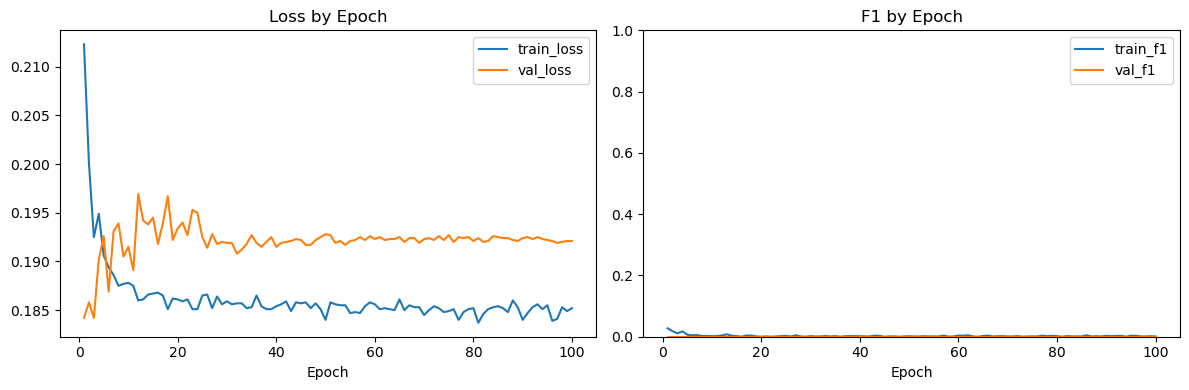

In [3]:
# 2) Training curves from log file (works while run is still ongoing)
if not LOG_FILE.exists():
    print("log file not found")
else:
    text = LOG_FILE.read_text(encoding="utf-8", errors="ignore")

    pattern = re.compile(
        r"Epoch:\s*(\d+)/(\d+),\s*"
        r"Train Loss:\s*([0-9.]+),\s*Train F1:\s*([0-9.]+),\s*"
        r"Val Loss:\s*([0-9.]+),\s*Val F1:\s*([0-9.]+)",
        flags=re.MULTILINE,
    )
    rows = [
        {
            "epoch": int(m.group(1)),
            "epochs_total": int(m.group(2)),
            "train_loss": float(m.group(3)),
            "train_f1": float(m.group(4)),
            "val_loss": float(m.group(5)),
            "val_f1": float(m.group(6)),
        }
        for m in pattern.finditer(text)
    ]

    curves_df = pd.DataFrame(rows)
    if curves_df.empty:
        print("No epoch lines parsed yet.")
    else:
        print(f"Parsed {len(curves_df)} epochs from log.")
        display(curves_df.tail(10))

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(curves_df["epoch"], curves_df["train_loss"], label="train_loss")
        axes[0].plot(curves_df["epoch"], curves_df["val_loss"], label="val_loss")
        axes[0].set_title("Loss by Epoch")
        axes[0].set_xlabel("Epoch")
        axes[0].legend()

        axes[1].plot(curves_df["epoch"], curves_df["train_f1"], label="train_f1")
        axes[1].plot(curves_df["epoch"], curves_df["val_f1"], label="val_f1")
        axes[1].set_title("F1 by Epoch")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylim(0, 1)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

=== Remaining Subjects Evaluation Set ===
X500 shape: (38850, 1, 13, 201)
Known subjects (n100): 100
Remaining unique subjects: 400
Remaining samples: 30227

=== Checkpoint n=10 ===
Accuracy=0.6000, BAcc=0.5000, AUC=0.6250


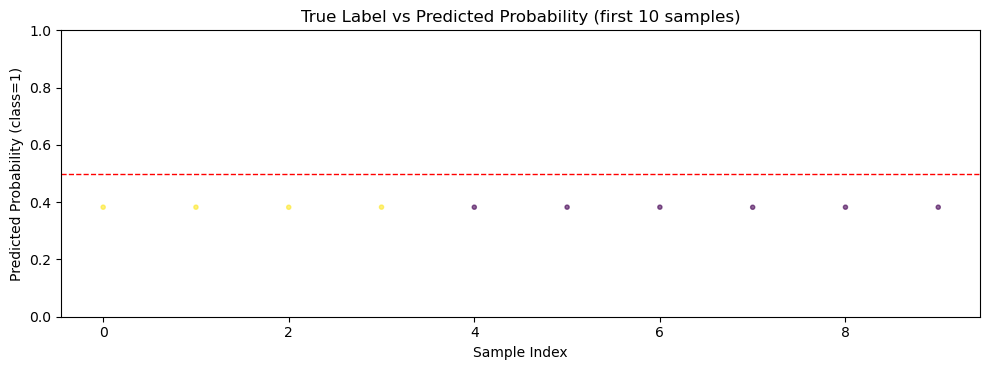


=== Checkpoint n=50 ===
Accuracy=0.5800, BAcc=0.5000, AUC=0.5583


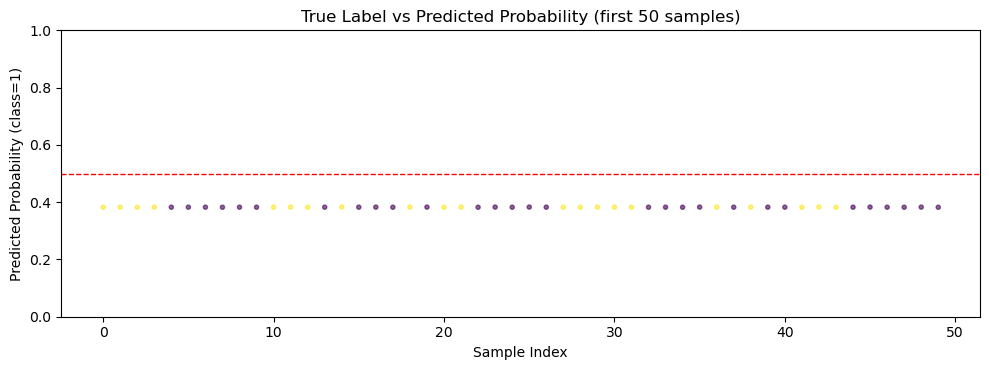


=== Checkpoint n=100 ===
Accuracy=0.3900, BAcc=0.5000, AUC=0.6679


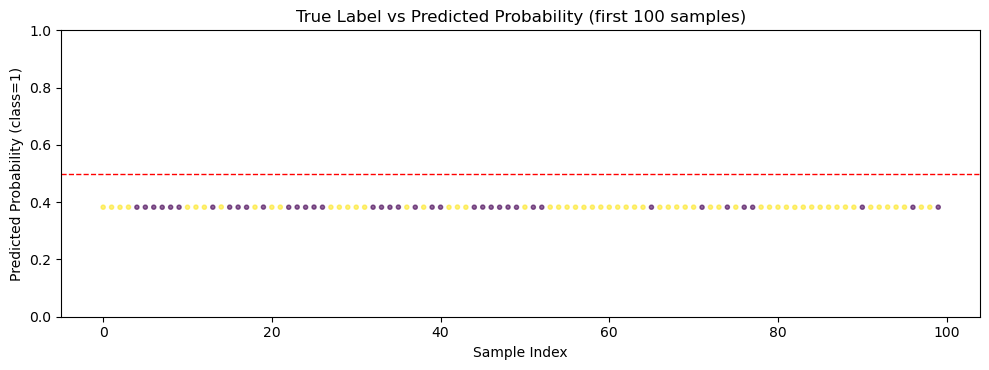


=== Checkpoint n=200 ===
Accuracy=0.3500, BAcc=0.5000, AUC=0.6189


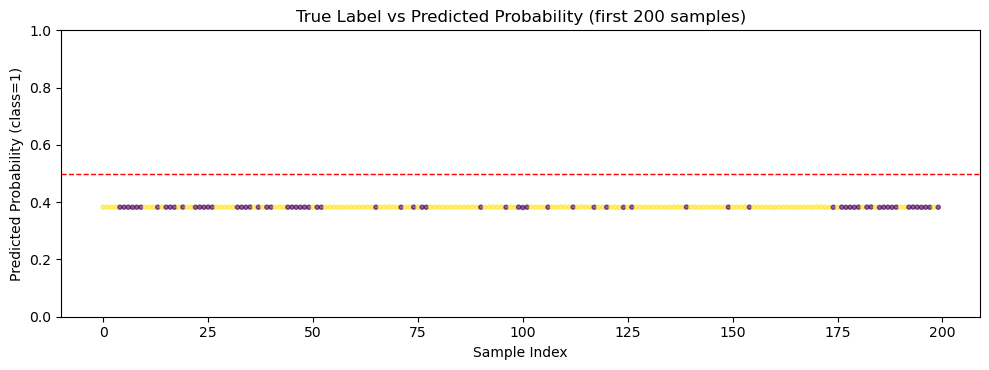


=== Checkpoint n=500 ===
Accuracy=0.2980, BAcc=0.5000, AUC=0.5196


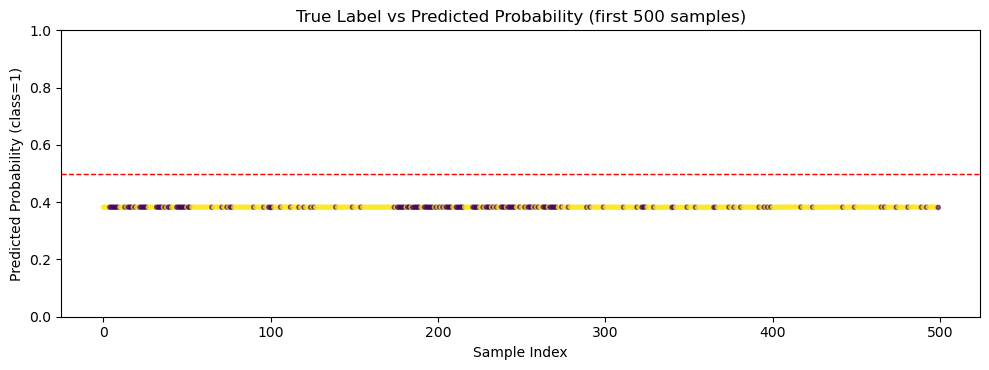


=== Checkpoint n=1000 ===
Accuracy=0.3730, BAcc=0.5000, AUC=0.4376


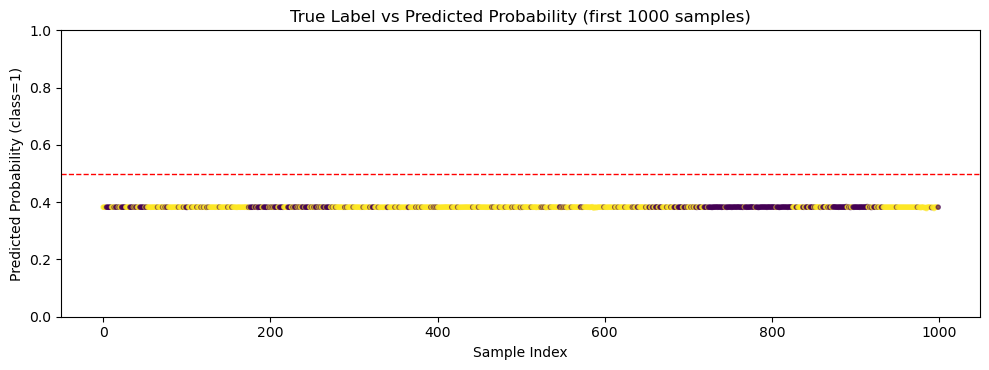


=== Checkpoint n=2000 ===
Accuracy=0.3690, BAcc=0.5000, AUC=0.4753


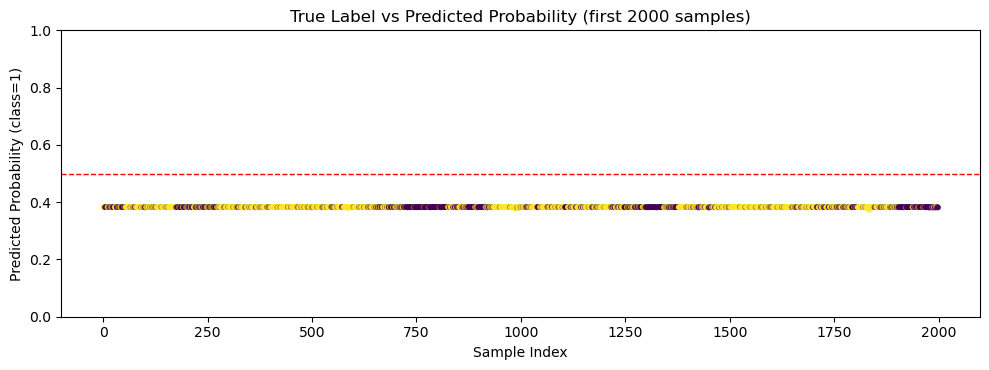


=== Checkpoint n=3000 ===
Accuracy=0.3277, BAcc=0.5000, AUC=0.4866


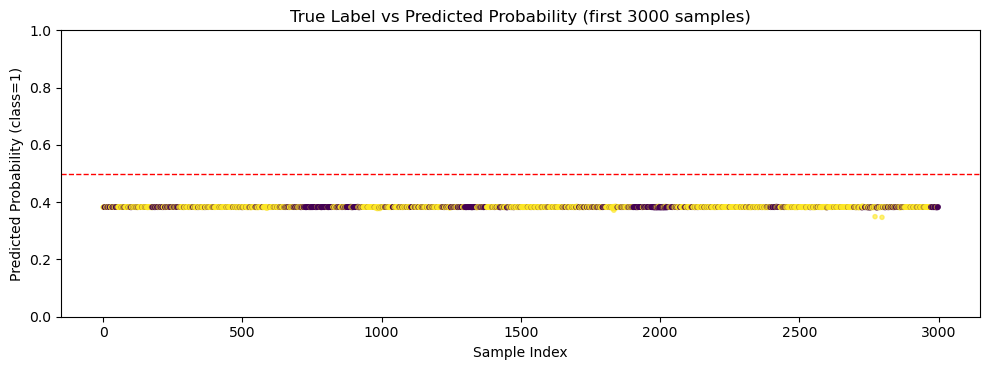


=== Checkpoint n=4000 ===
Accuracy=0.3372, BAcc=0.5000, AUC=0.4935


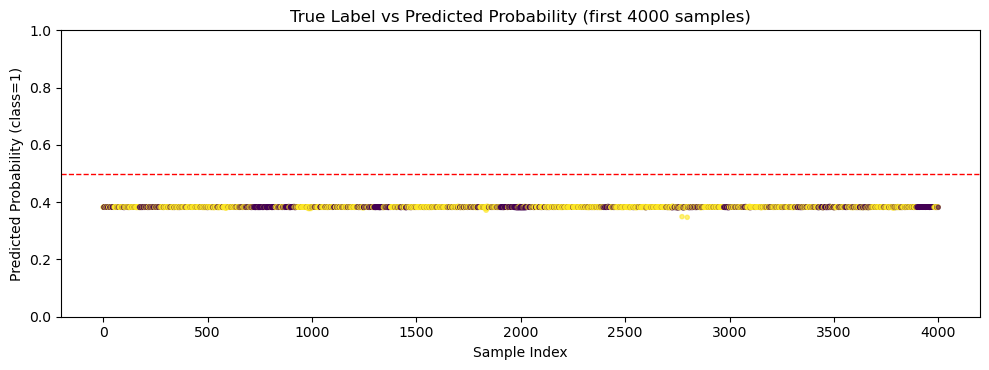


=== Checkpoint n=5000 ===
Accuracy=0.3264, BAcc=0.5000, AUC=0.4889


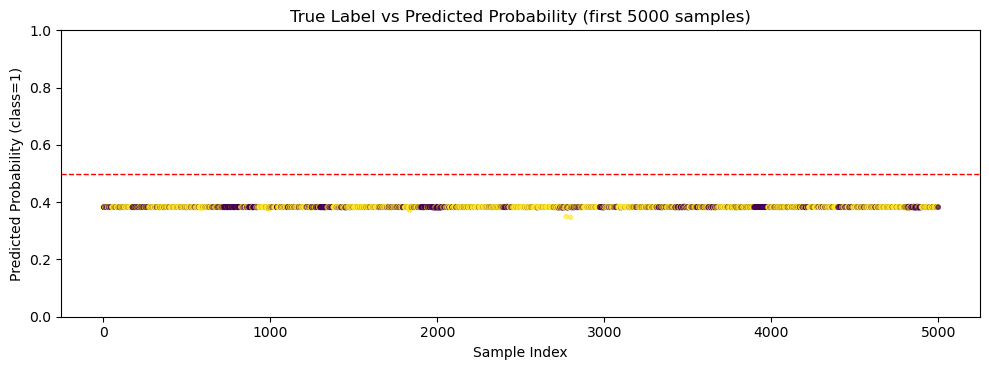

KeyboardInterrupt: 

In [4]:
# 3) Evaluate focal model on remaining subjects with progressive checkpoints
from pathlib import Path
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

HASH_SUFFIX = "6b3c980fa74c"
CACHE_DIR = Path("/mount/NAS-workspace-portal/eeg2025-Vistec/models/data")

X500_path = CACHE_DIR / f"X_ccd_eegnet_n500_p{HASH_SUFFIX}.npy"
y500_path = CACHE_DIR / f"y_ccd_eegnet_n500_p{HASH_SUFFIX}.npy"
g500_path = CACHE_DIR / f"groups_ccd_eegnet_n500_p{HASH_SUFFIX}.npy"

X100_path = CACHE_DIR / f"X_ccd_eegnet_n100_p{HASH_SUFFIX}.npy"
g100_path = CACHE_DIR / f"groups_ccd_eegnet_n100_p{HASH_SUFFIX}.npy"

required = [X500_path, y500_path, g500_path, X100_path, g100_path]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing cache files:\n" + "\n".join(missing))

X500 = np.load(X500_path)
y500 = np.load(y500_path).astype(np.int64)
g500 = np.load(g500_path).astype(str)

g100 = np.load(g100_path).astype(str)
known_subjects = np.unique(g100)
remain_mask = ~np.isin(g500, known_subjects)

X_remain = X500[remain_mask].astype(np.float32, copy=False)
y_remain = y500[remain_mask].astype(np.int64, copy=False)
g_remain = g500[remain_mask]

print("=== Remaining Subjects Evaluation Set ===")
print(f"X500 shape: {X500.shape}")
print(f"Known subjects (n100): {len(known_subjects)}")
print(f"Remaining unique subjects: {len(np.unique(g_remain))}")
print(f"Remaining samples: {len(X_remain)}")

# Load EEGNet class from train_classify.py
train_file = Path("/mount/NAS-workspace-portal/eeg2025-Vistec/AI_notebook/Deep/EEGNet/train_classify.py")
spec = importlib.util.spec_from_file_location("train_classify", str(train_file))
if spec is None or spec.loader is None:
    raise ImportError(f"Cannot load module from {train_file}")
train_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(train_mod)
EEGNet = train_mod.EEGNet

# Use focal+weighted sampler trained model
MODEL_PATH = Path("/mount/NAS-workspace-portal/eeg2025-Vistec/jobs/notebook_binary_run/model.pt")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model checkpoint not found: {MODEL_PATH}")

device = torch.device("cpu")
model = EEGNet(
    Chans=X_remain.shape[2],
    Samples=X_remain.shape[3],
    dropoutRate=0.5,
    kernLength=64,
    F1=8,
    D=2,
    F2=16,
    norm_rate=0.25,
    dropoutType="Dropout",
).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval()

batch_size = 512
checkpoints = [10, 50, 100, 200, 500, 1000, 2000, 3000, 4000, 5000]
checkpoints = [c for c in checkpoints if c <= len(X_remain)]
if len(X_remain) not in checkpoints:
    checkpoints.append(len(X_remain))
checkpoints = sorted(set(checkpoints))

probs_accum = []
preds_accum = []
next_ckpt_idx = 0

for i in range(0, len(X_remain), batch_size):
    xb = torch.from_numpy(X_remain[i:i + batch_size]).to(device)
    with torch.no_grad():
        logits = model(xb)
        p1 = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        yhat = np.argmax(logits.cpu().numpy(), axis=1)

    probs_accum.extend(p1.tolist())
    preds_accum.extend(yhat.tolist())

    n_done = len(probs_accum)
    while next_ckpt_idx < len(checkpoints) and n_done >= checkpoints[next_ckpt_idx]:
        n_eval = checkpoints[next_ckpt_idx]
        y_true_k = y_remain[:n_eval]
        prob_k = np.asarray(probs_accum[:n_eval])
        pred_k = np.asarray(preds_accum[:n_eval], dtype=np.int64)

        acc_k = accuracy_score(y_true_k, pred_k)
        bacc_k = balanced_accuracy_score(y_true_k, pred_k)
        auc_k = roc_auc_score(y_true_k, prob_k) if len(np.unique(y_true_k)) == 2 else np.nan

        print(f"\n=== Checkpoint n={n_eval} ===")
        print(f"Accuracy={acc_k:.4f}, BAcc={bacc_k:.4f}, AUC={auc_k:.4f}")

        plt.figure(figsize=(10, 3.8))
        idx = np.arange(n_eval)
        plt.scatter(idx, prob_k, c=y_true_k, s=9, alpha=0.6)
        plt.axhline(0.5, color="red", linestyle="--", linewidth=1)
        plt.title(f"True Label vs Predicted Probability (first {n_eval} samples)")
        plt.xlabel("Sample Index")
        plt.ylabel("Predicted Probability (class=1)")
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()

        next_ckpt_idx += 1

prob_1 = np.asarray(probs_accum)
y_pred = np.asarray(preds_accum, dtype=np.int64)

summary_df = pd.DataFrame(
    [{
        "n_samples": len(y_remain),
        "n_subjects": len(np.unique(g_remain)),
        "accuracy": accuracy_score(y_remain, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_remain, y_pred),
        "roc_auc": roc_auc_score(y_remain, prob_1) if len(np.unique(y_remain)) == 2 else np.nan,
    }]
 )
print("\n=== Remaining Subject Metrics (Full) ===")
display(summary_df)

pred_df = pd.DataFrame({
    "subject": g_remain,
    "y_true": y_remain,
    "prob_1": prob_1,
    "y_pred": y_pred,
})
display(pred_df.head(20))

plt.figure(figsize=(7, 4))
for cls in [0, 1]:
    vals = pred_df.loc[pred_df["y_true"] == cls, "prob_1"].values
    if len(vals) > 0:
        plt.hist(vals, bins=40, alpha=0.5, density=True, label=f"true={cls}")
plt.title("Probability Distribution by True Class (Full)")
plt.xlabel("Predicted Probability (class=1)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()